# **MÓDULO 13**
# Projeto - Fundamentos da Descoberta de Dados

Nesse projeto trabalharemos com a base de dados de produtos de um supermercado do Chile.
A ideia é que vocês apliquem os conceitos estatísticos vistos no último módulo, mais os conceitos de visualizações de dados através de gráficos e finalizem publicando no seu github!

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

Faça a leitura dos dados do arquivo CSV:


Altere o código abaixo de acordo com seu diretório.

In [2]:
from pathlib import Path

# Caminho relativo à pasta do notebook (funciona em qualquer máquina)
ARQUIVO = Path("MODULO7_PROJETOFINAL_BASE_SUPERMERCADO - MODULO7_PROJETOFINAL_BASE_SUPERMERCADO (1).csv.csv")

df = pd.read_csv(
    ARQUIVO,
    sep=",",  # o arquivo é separado por vírgula (aspas protegem vírgulas no título)
    dtype={
        "title": "string",
        "Marca": "category",
        "Categoria": "category",
        "Preco_Normal": "int32",
        "Preco_Desconto": "int32",
        "Preco_Anterior": "int32",
    },
)

df.head(10)

,title,Marca,Preco_Normal,Preco_Desconto,Preco_Anterior,Desconto,Categoria
0,"Pack 12 un, Leche extra proteína 1 L",Loncoleche,19788,0,0,0,lacteos
1,"Pack 12 un, Leche chocolate receta original 1 L",Soprole,18228,0,0,0,lacteos
2,"Pack 12 un, Leche semidescremada chocolate 1 L",Soprole,18228,0,0,0,lacteos
3,"Pack 12 un, Leche semidescremada frutilla 1 L",Soprole,18228,0,0,0,lacteos
4,"Pack 12 un, Leche sin lactosa chocolate 1 L",Loncoleche,17988,0,0,0,lacteos
5,"Pack 12 un, Leche sin lactosa frutilla 1 L",Loncoleche,17988,0,0,0,lacteos
6,"Pack 12 un, Leche saborizada light chocolate 1 L",Loncoleche,17988,0,0,0,lacteos
7,"Pack 12 un, Leche saborizada frutilla 1 L",Colun,17388,0,0,0,lacteos
8,"Pack 12 un, Leche saborizada vainilla 1 L",Colun,17388,0,0,0,lacteos
9,"Pack 12 un, Leche saborizada manjar 1 L",Colun,17388,0,0,0,lacteos


Os campos do nosso dataframe são:

**Title:** Nome do produto.


**Marca:** A marca do produto.


**Preco_Normal:** O preço em que o produto costuma ser vendido quando não há desconto.


**Preco_Desconto:** O preço vendido após o desconto ser aplicado.


**Preco_Anterior:** Preço em que era comercializado o produto antes do desconto aplicado.


**Desconto:** Total de desconto aplicado.






As colunas que aparecem com valores 0 são para os produtos onde não tivemos descontos aplicados.


As categorias estão em espanhol!

# 1 - Traga a média e a mediana dos preços - coluna Preco_Normal - por categoria de produto.
# Identifique as categorias que parecem ter um valor de média abaixo ou acima da mediana.

In [3]:
media = df.groupby("Categoria", observed=True)["Preco_Normal"].mean().round(1)
media

Categoria
belleza-y-cuidado-personal    1783.6
comidas-preparadas            3095.0
congelados                    2108.0
frutas                        1724.5
instantaneos-y-sopas           765.5
lacteos                       2385.2
verduras                      1343.3
Name: Preco_Normal, dtype: float64

In [4]:
mediana = df.groupby("Categoria", observed=True)["Preco_Normal"].median()

# Comparação: diferença positiva = média acima da mediana
comparacao = pd.DataFrame({"media": media, "mediana": mediana})
comparacao["media - mediana"] = (comparacao["media"] - comparacao["mediana"]).round(1)
comparacao.sort_values("media - mediana", ascending=False)

,media,mediana,media - mediana
Categoria,,,
lacteos,2385.2,989.0,1396.2
congelados,2108.0,1519.0,589.0
frutas,1724.5,1195.0,529.5
instantaneos-y-sopas,765.5,439.0,326.5
belleza-y-cuidado-personal,1783.6,1569.0,214.6
verduras,1343.3,1180.0,163.3
comidas-preparadas,3095.0,3290.0,-195.0


**Média acima da mediana** (distribuição assimétrica à direita, puxada por produtos caros): todas as categorias abaixo, com destaque para as maiores diferenças:
- **lacteos** (média 2385 vs mediana 989, +1396) – a maior diferença
- **congelados** (+589)
- **frutas** (+530)
- **instantaneos-y-sopas** (+327)
- belleza-y-cuidado-personal (+215) e verduras (+163), diferenças menores

**Média abaixo da mediana:**
- **comidas-preparadas** (3095 vs 3290, −195) – única categoria nesse caso, indicando alguns preços baixos puxando a média para baixo.

# 2 - Traga o desvio padrão por categoria de produto.
# Qual o comportamento da média e mediana nas categorias com maior desvio?

In [5]:
desvio = df.groupby("Categoria", observed=True)["Preco_Normal"].std().round(1)

# Junta com média e mediana para comparar, ordenando pelo maior desvio
resumo = pd.DataFrame({"media": media, "mediana": mediana, "desvio_padrao": desvio})
resumo["media - mediana"] = (resumo["media"] - resumo["mediana"]).round(1)
resumo.sort_values("desvio_padrao", ascending=False)

,media,mediana,desvio_padrao,media - mediana
Categoria,,,,
lacteos,2385.2,989.0,3925.8,1396.2
belleza-y-cuidado-personal,1783.6,1569.0,2210.0,214.6
congelados,2108.0,1519.0,2111.5,589.0
comidas-preparadas,3095.0,3290.0,2019.9,-195.0
frutas,1724.5,1195.0,1639.2,529.5
instantaneos-y-sopas,765.5,439.0,1170.2,326.5
verduras,1343.3,1180.0,1012.7,163.3


As categorias com maior desvio padrão são **lacteos** (≈3926), **belleza-y-cuidado-personal** (≈2210) e **congelados** (≈2112).

Nelas, a **média fica bem acima da mediana** (lacteos: 2385 vs 989; congelados: 2108 vs 1519; belleza: 1784 vs 1569). Ou seja, há muita dispersão e uma cauda de produtos caros (outliers) puxando a média para cima, enquanto a mediana continua representando o preço "típico". Em lacteos isso é mais extremo: o desvio é maior que a própria média.

Já nas categorias com menor desvio (verduras, instantaneos-y-sopas), média e mediana ficam mais próximas em termos relativos.

# 3 - Plot um boxplot da distribuição do Preco_Normal para a categoria que você identificou que tem o maior desvio padrão. Como é a distribuição desses dados segundo o boxplot? Você identifica muitos outliers?

Dica: Para trazer apenas os dados da categoria que você deseja você pode usar o df.loc[df['Categoria'] == 'CATEGORIA ESCOLHIDA'

C:\Users\AOJESP\AppData\Local\Temp\ipykernel_25700\3590161710.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(dados, vert=False)


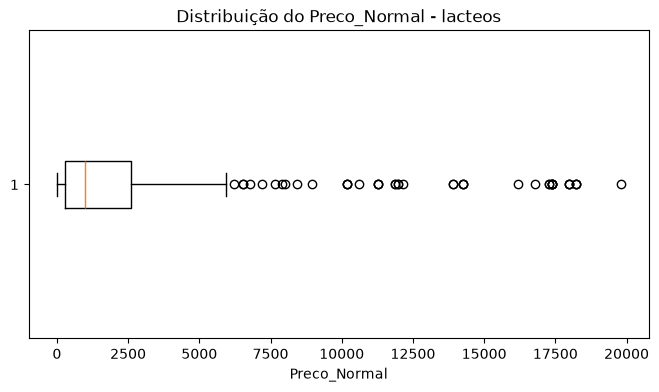

Mediana: 989 | Q1: 269 | Q3: 2609 | Limite superior: 6119
Outliers: 43 de 447 produtos


In [6]:
categoria_maior_desvio = desvio.idxmax()  # lacteos
dados = df.loc[df["Categoria"] == categoria_maior_desvio, "Preco_Normal"]

plt.figure(figsize=(8, 4))
plt.boxplot(dados, vert=False)
plt.title(f"Distribuição do Preco_Normal - {categoria_maior_desvio}")
plt.xlabel("Preco_Normal")
plt.show()

# Outliers pelo critério do boxplot (1,5 x IQR)
q1, q3 = dados.quantile([0.25, 0.75])
limite_superior = q3 + 1.5 * (q3 - q1)
print(f"Mediana: {dados.median():.0f} | Q1: {q1:.0f} | Q3: {q3:.0f} | Limite superior: {limite_superior:.0f}")
print(f"Outliers: {(dados > limite_superior).sum()} de {len(dados)} produtos")

**Distribuição (lacteos):** assimétrica à direita. A caixa (Q1 = 269 a Q3 = 2609) é larga, a mediana (989) fica na metade inferior dela e o "bigode" superior é longo.

**Outliers:** sim, muitos. São **43 de 447 produtos (~10%)** acima do limite superior (≈6119), chegando a 19788 (packs de 12 unidades). Não há outliers na parte inferior. Isso explica a média (2385) muito acima da mediana (989).

# 4 - Plote um gráfico de barras onde temos a média de descontos por categoria.

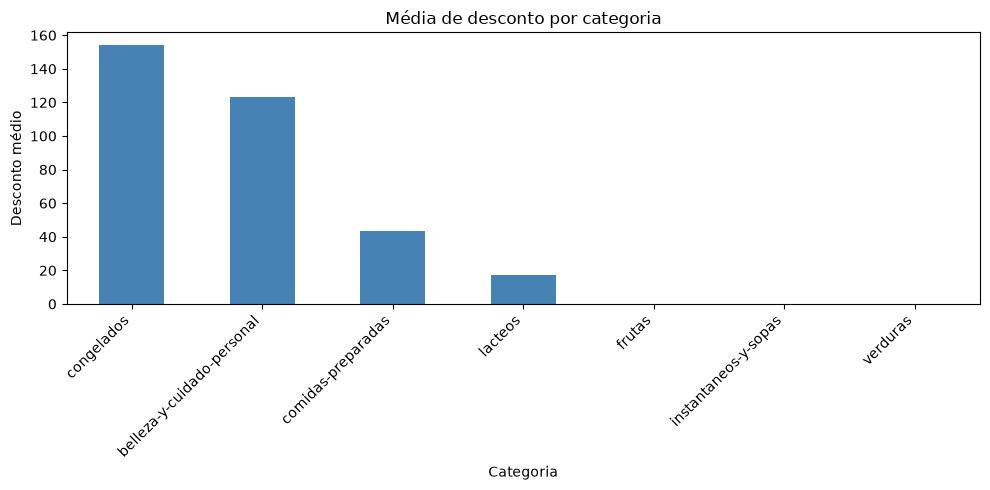

In [7]:
media_desconto = (
    df.groupby("Categoria", observed=True)["Desconto"].mean().sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
media_desconto.plot(kind="bar", color="steelblue")
plt.title("Média de desconto por categoria")
plt.xlabel("Categoria")
plt.ylabel("Desconto médio")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 5 - Plote um gráfico de mapa interativo agrupando os dados por categoria, marca e trazendo a média de desconto.

In [8]:
desconto_marca = (
    df.groupby(["Categoria", "Marca"], observed=True)["Desconto"].mean().reset_index()
)

# Treemap: área proporcional ao desconto médio (só combinações com desconto > 0)
fig = px.treemap(
    desconto_marca[desconto_marca["Desconto"] > 0],
    path=["Categoria", "Marca"],
    values="Desconto",
    color="Desconto",
    color_continuous_scale="Blues",
    title="Média de desconto por categoria e marca",
)
fig.show()